In [3]:
from typing import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph,START,END
from loguru import logger


#1. 构建子图
#1.1 声明子图的状态
class SubgraphState(TypedDict):
    raw_text:str #未清洗的文本
    stripped_text:str # 去除首尾的空格
    punctuated_text:str # 句尾添加句号

#1.2 声明子图的节点 -> 去除空格的节点
def subgraph_strip_node(state:SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()
    logger.info("调用子图中的strip节点")
    return {
        "stripped_text":stripped_text
    }

#1.3 添加句号的节点
def subgraph_punctuated_node(state:SubgraphState) -> SubgraphState:
    stripped_text = state["stripped_text"]
    punctuated_text = stripped_text + '。'
    logger.info("调用子图中的punctuated节点")
    return {
        "punctuated_text":punctuated_text
    }

#1.4 构建子图
builder = StateGraph(state_schema=SubgraphState)
builder.add_node("subgraph_strip_node",subgraph_strip_node)
builder.add_node("subgraph_punctuated_node",subgraph_punctuated_node)
builder.add_edge(START,"subgraph_strip_node")
builder.add_edge("subgraph_strip_node","subgraph_punctuated_node")
builder.add_edge("subgraph_punctuated_node",END)
subgraph = builder.compile()


In [4]:
#2.构建父图
#2.1 声明状态
class ParentState(TypedDict):
    input_text:str
    cleaned_text:str

#2.2 声明节点 => 调用子图节点
def call_subgraph(state:ParentState)->ParentState:
    input_text = state["input_text"]
    res = subgraph.invoke({"raw_text":input_text})
    cleaned_text = res["punctuated_text"]
    return {
        "cleaned_text":cleaned_text
    }

#2.3 构建父图
parent_builder = StateGraph(state_schema=ParentState)
parent_builder.add_node("call_subgraph",call_subgraph)
parent_builder.add_edge(START,"call_subgraph")
parent_builder.add_edge("call_subgraph",END)

# 添加检查点信息
checkpointer = InMemorySaver()
parent_graph = parent_builder.compile(checkpointer=checkpointer)

# 添加检查点之后 必须填写config 才能执行
config = {"configurable":{"thread_id":"123"}}

#2.4 调用父图 => 内部函数会调用子图
res = parent_graph.invoke({"input_text":"    langgraph真好玩   "},config = config)
print(res)

2026-07-14 10:23:52.801 | INFO     | __main__:subgraph_strip_node:19 - 调用子图中的strip节点
2026-07-14 10:23:52.803 | INFO     | __main__:subgraph_punctuated_node:28 - 调用子图中的punctuated节点


{'input_text': '    langgraph真好玩   ', 'cleaned_text': 'langgraph真好玩。'}


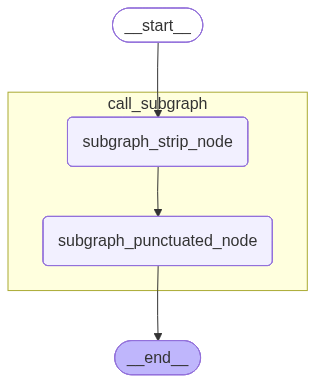

In [5]:
from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)

In [6]:
histories = list(parent_graph.get_state_history(config=config))
histories

[StateSnapshot(values={'input_text': '    langgraph真好玩   ', 'cleaned_text': 'langgraph真好玩。'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17f2b0-e74c-6f67-8001-d21a1bbd3a18'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-14T02:23:52.805350+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17f2b0-e73c-6ecb-8000-522abf6fd38c'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input_text': '    langgraph真好玩   '}, next=('call_subgraph',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17f2b0-e73c-6ecb-8000-522abf6fd38c'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-14T02:23:52.798779+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17f2b0-e739-608c-bfff-a63243b8dcbc'}}, tasks=(PregelTask(id='7e155ccb-6c48-8d53-9810-97b90c930ecf', name='

In [7]:
parent_config = histories[-2].config
parent_config

{'configurable': {'thread_id': '123',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17f2b0-e73c-6ecb-8000-522abf6fd38c'}}

In [8]:
# 查看嵌入的子图检查点信息 => 只需要查看父检查点调用子图的位置 => 添加参数 subgraphs=True
parent_graph.get_state(config=parent_config, subgraphs=True)

StateSnapshot(values={'input_text': '    langgraph真好玩   '}, next=('call_subgraph',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17f2b0-e73c-6ecb-8000-522abf6fd38c'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-14T02:23:52.798779+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17f2b0-e739-608c-bfff-a63243b8dcbc'}}, tasks=(PregelTask(id='7e155ccb-6c48-8d53-9810-97b90c930ecf', name='call_subgraph', path=('__pregel_pull', 'call_subgraph'), error=None, interrupts=(), state=StateSnapshot(values={'raw_text': '    langgraph真好玩   ', 'stripped_text': 'langgraph真好玩', 'punctuated_text': 'langgraph真好玩。'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': 'call_subgraph:7e155ccb-6c48-8d53-9810-97b90c930ecf', 'checkpoint_id': '1f17f2b0-e74b-60a9-8002-7a2f976b81ef', 'checkpoint_map': {'': '1f17f2b0-e73c-6ecb-8000-522abf6fd38c', 'call_subgraph:7e155ccb-6c4

In [9]:
subgraph_config = histories[-2].tasks[0].state
subgraph_config

{'configurable': {'thread_id': '123',
  'checkpoint_ns': 'call_subgraph:7e155ccb-6c48-8d53-9810-97b90c930ecf'}}

In [10]:
# 在检查点记录时 => 使用checkpoint_ns来区别不同的子图
list(parent_graph.get_state_history(config=subgraph_config))

[StateSnapshot(values={'raw_text': '    langgraph真好玩   ', 'stripped_text': 'langgraph真好玩', 'punctuated_text': 'langgraph真好玩。'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': 'call_subgraph:7e155ccb-6c48-8d53-9810-97b90c930ecf', 'checkpoint_id': '1f17f2b0-e74b-60a9-8002-7a2f976b81ef', 'checkpoint_map': {'': '1f17f2b0-e73c-6ecb-8000-522abf6fd38c', 'call_subgraph:7e155ccb-6c48-8d53-9810-97b90c930ecf': '1f17f2b0-e74b-60a9-8002-7a2f976b81ef'}}}, metadata={'source': 'loop', 'step': 2, 'parents': {'': '1f17f2b0-e73c-6ecb-8000-522abf6fd38c'}}, created_at='2026-07-14T02:23:52.804562+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': 'call_subgraph:7e155ccb-6c48-8d53-9810-97b90c930ecf', 'checkpoint_id': '1f17f2b0-e746-6d9c-8001-4c1ef6282782', 'checkpoint_map': {'': '1f17f2b0-e73c-6ecb-8000-522abf6fd38c', 'call_subgraph:7e155ccb-6c48-8d53-9810-97b90c930ecf': '1f17f2b0-e746-6d9c-8001-4c1ef6282782'}}}, tasks=(), interrupts=()),
 StateSnapshot(value